# Ridge Regression - Key Concepts

## 1. How the Coefficients Get Affected

### Ridge Regression Cost Function

$$
J(\beta_0,\beta_1,\dots,\beta_p)
=
\sum_{i=1}^{n}
\left(
y_i -
\left(
\beta_0 + \beta_1x_{i1} + \beta_2x_{i2} + \dots + \beta_px_{ip}
\right)
\right)^2
+
\lambda
\sum_{j=1}^{p}\beta_j^2
$$

Where:

- \( y_i \) = Actual value  
- \( \hat{y}_i \) = Predicted value  
- \( \beta_j \) = Coefficients  
- \( \lambda \) = Regularization parameter  

### Effect
- Coefficients shrink toward zero.
- Prevents overfitting.

---

# 2. Higher Values are Impacted More

### Penalty Term

$$
\lambda
\left(
\beta_1^2 + \beta_2^2 + \dots + \beta_p^2
\right)
$$

If coefficients become large:

$$
\beta_j^2 \uparrow
\quad \Rightarrow \quad
\text{Penalty} \uparrow
$$

### Effect
- Large coefficients receive stronger punishment.
- Model becomes more stable.

---

# 3. Bias-Variance Tradeoff

### Total Error Formula

$$
\text{Total Error}
=
\text{Bias}^2
+
\text{Variance}
+
\text{Irreducible Error}
$$

### With Ridge Regression

If:

$$
\lambda \uparrow
$$

Then:

$$
\text{Bias} \uparrow
$$

and

$$
\text{Variance} \downarrow
$$

### Meaning
- Small \( \lambda \) → flexible model
- Large \( \lambda \) → simpler model

---

# 4. Contour Plots

### Ridge Constraint Region

$$
\sum_{j=1}^{p}\beta_j^2 \leq t
$$

For 2 variables:

$$
\beta_1^2 + \beta_2^2 \leq t
$$

This forms a circular region.

### Interpretation
- Ridge shrinks coefficients smoothly.
- Most coefficients remain non-zero.

---

## 5. Why it is Called Ridge Regression
- The penalty term creates a “ridge” in the cost function surface.
- This stabilizes coefficient estimation.
- Especially useful when multicollinearity exists.

### Multicollinearity
- Happens when independent variables are highly correlated.
- Ridge reduces instability caused by correlated features.

---

# Practical Tip

## Standardization Formula

$$
z
=
\frac{x-\mu}{\sigma}
$$

Where:

- \( \mu \) = Mean  
- \( \sigma \) = Standard deviation  


- Always standardize features before applying Ridge Regression.
- Use cross-validation to choose the best \(\lambda\) value.
- Works well when:
  - Many features exist
  - Features are correlated
  - Overfitting is present

# 1.How coefficients are affected?


In [1]:
from sklearn.datasets import load_diabetes

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


In [2]:
data = load_diabetes()


In [3]:

df = pd.DataFrame(data.data,columns=data.feature_names)
df['TARGET'] = data.target

In [4]:
df.head()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,TARGET
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [5]:
df.shape


(442, 11)

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(data.data,data.target,test_size=0.2,random_state=2)


In [7]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

In [8]:
coefs = []
r2_scores = []

for i in [0,10,100,1000]:
    reg = Ridge(alpha=i)
    reg.fit(X_train,y_train)
    
    coefs.append(reg.coef_.tolist())
    y_pred = reg.predict(X_test)
    r2_scores.append(r2_score(y_test,y_pred))

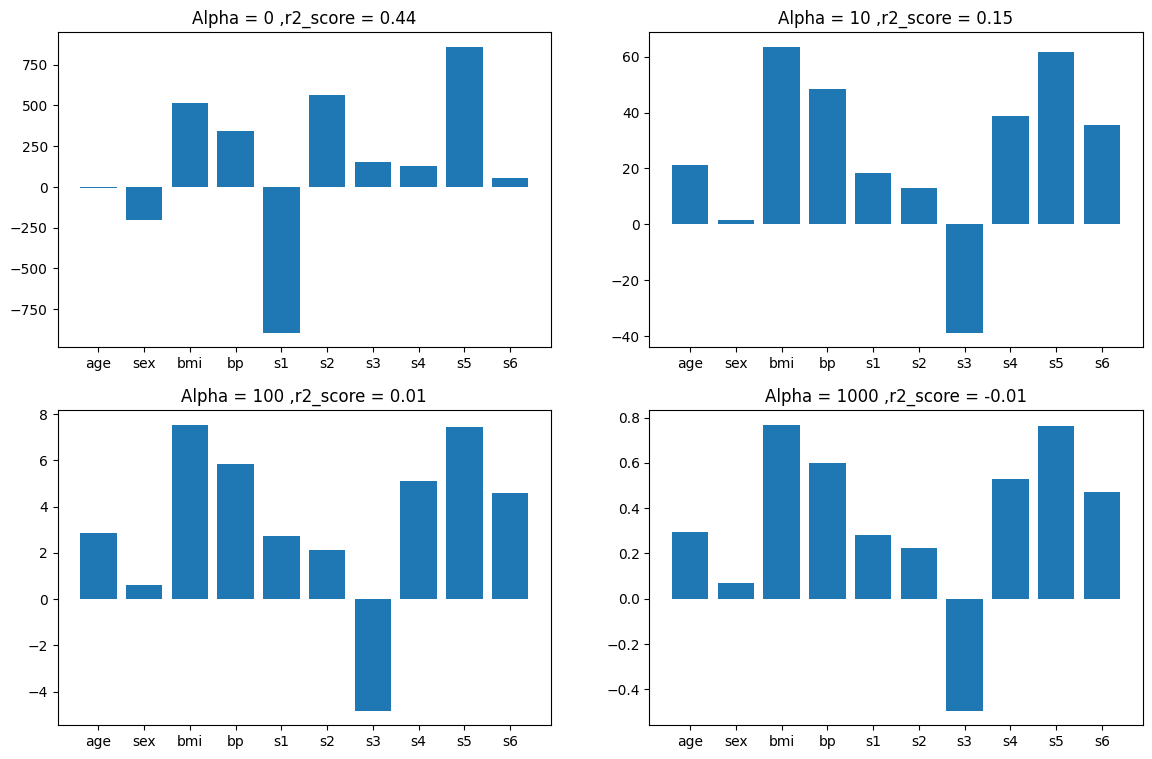

In [9]:
plt.figure(figsize=(14,9))
plt.subplot(221)
plt.bar(data.feature_names,coefs[0])
plt.title('Alpha = 0 ,r2_score = {}'.format(round(r2_scores[0],2)))

plt.subplot(222)
plt.bar(data.feature_names,coefs[1])
plt.title('Alpha = 10 ,r2_score = {}'.format(round(r2_scores[1],2)))

plt.subplot(223)
plt.bar(data.feature_names,coefs[2])
plt.title('Alpha = 100 ,r2_score = {}'.format(round(r2_scores[2],2)))

plt.subplot(224)
plt.bar(data.feature_names,coefs[3])
plt.title('Alpha = 1000 ,r2_score = {}'.format(round(r2_scores[3],2)))

plt.show()


# 2. Higher Coefficients are affected more

In [10]:
alphas = [0,0.0001,0.001,0.01,0.1,1,10,100,1000,10000]


In [11]:

for i in alphas:
    reg = Ridge(alpha=i)
    reg.fit(X_train,y_train)
    
    coefs.append(reg.coef_.tolist())

In [12]:
input_array = np.array(coefs)


In [15]:
alphas = [0,0.0001,0.0005,0.001,0.005,0.1,0.5,1,5,10]

coefs = []

for i in alphas:
    reg = Ridge(alpha=i)
    reg.fit(X_train,y_train)
    
    coefs.append(reg.coef_.tolist())

In [16]:
input_array = np.array(coefs).T


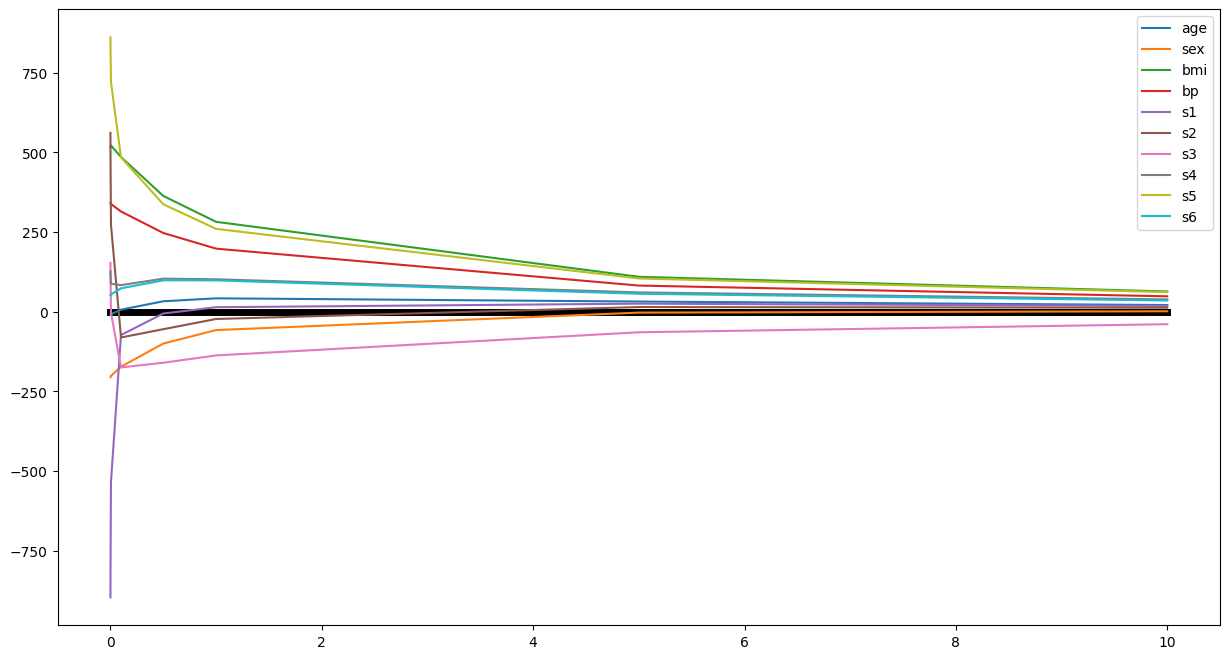

In [17]:
plt.figure(figsize=(15,8))
plt.plot(alphas,np.zeros(len(alphas)),color='black',linewidth=5)
for i in range(input_array.shape[0]):
    plt.plot(alphas,input_array[i],label=data.feature_names[i])
plt.legend()

# 3.Impact on Bias and Variance

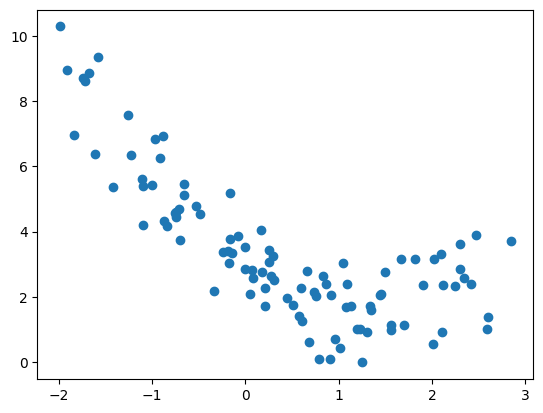

In [18]:
m = 100
X = 5 * np.random.rand(m, 1) - 2
y = 0.7 * X ** 2 - 2 * X + 3 + np.random.randn(m, 1)

plt.scatter(X, y)
plt.show()


In [19]:
X_train,X_test,y_train,y_test = train_test_split(X.reshape(100,1),y.reshape(100),test_size=0.2,random_state=2)


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=15)

X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

In [ ]:
from mlxtend.evaluate import bias_variance_decomp

alphas = np.linspace(0,30,100)

loss = []
bias = []
variance = []

for i in alphas:
    reg = Ridge(alpha=i)
    avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(
        reg, X_train, y_train, X_test, y_test, 
        loss='mse',
        random_seed=123)
    loss.append(avg_expected_loss)
    bias.append(avg_bias)
    variance.append(avg_var)


In [ ]:
plt.plot(alphas,loss,label='loss')
plt.plot(alphas,bias,label='Bias')
plt.plot(alphas,variance,label='Variance')
plt.ylim(0,5)
plt.xlabel('Alpha')
plt.legend()
plt.show()

# 4. Effect of Regularization on Loss Function

In [ ]:
from sklearn.datasets import make_regression

X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

plt.scatter(X,y)

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X,y)
print(reg.coef_)
print(reg.intercept_)

In [ ]:
def cal_loss(m,alpha):
    return np.sum((y - m*X.ravel() + 2.29)**2) + alpha*m*m

In [ ]:

def predict(m):
    return m*X - 2.29


In [ ]:

m = np.linspace(-45,100,100)
plt.figure(figsize=(4,6))
for j in [0,10,20,30,40,50,100]:
    loss = []
    for i in range(m.shape[0]):
        loss_i = cal_loss(m[i],j)
        loss.append(loss_i)
    plt.plot(m,loss,label='alpha = {}'.format(j))
plt.legend()
plt.xlabel('Alpha')
plt.ylabel('Loss')
plt.show()
